In [49]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler

## 1. Công thức tính CLV (Customer Lifetime Value)

**CLV** là tổng giá trị (thường là lợi nhuận hoặc doanh thu) mà một khách hàng đóng góp cho doanh nghiệp trong suốt toàn bộ mối quan hệ của họ với thương hiệu.

### Công thức cơ bản:
Dành cho việc tính toán dựa trên dữ liệu quá khứ:
$$CLV = \text{Giá trị đơn hàng trung bình} \times \text{Tần suất mua hàng} \times \text{Tuổi thọ khách hàng}$$

Trong đó, Tuổi thọ khách hàng có thể được tính bằng công thức: $$\text{Tuổi thọ khách hàng} = \frac{1}{\text{Tỷ lệ rời bỏ (Churn)}}$$

In [50]:
df = pd.read_csv('Dataset/Cleaned_data/master_df.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             52924 non-null  int64  
 1   Transaction_ID         52924 non-null  int64  
 2   Transaction_Date       52924 non-null  str    
 3   Month                  52924 non-null  str    
 4   Date                   52924 non-null  str    
 5   Week                   52924 non-null  str    
 6   Product_SKU            52924 non-null  str    
 7   Product_Description    52924 non-null  str    
 8   Product_Category       52924 non-null  str    
 9   ABC                    52924 non-null  str    
 10  Quantity               52924 non-null  int64  
 11  Avg_Price              52924 non-null  float64
 12  Delivery_Charges       52924 non-null  float64
 13  Revenue                52924 non-null  float64
 14  total_revenue          52924 non-null  float64
 15  Invoice      

In [51]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
today = df['Transaction_Date'].max() + dt.timedelta(days=1)
df['Length'] = (today - df.groupby('CustomerID')['Transaction_Date'].transform('min')).dt.days

In [52]:
from lifetimes.utils import summary_data_from_transaction_data

# 1. Chuyển đổi dữ liệu giao dịch thành bảng Summary (RFM)
# Thư viện sẽ tự tính Recency, Frequency, T (L) và Monetary chuẩn xác
rfm_summary = summary_data_from_transaction_data(
    df, 
    customer_id_col='CustomerID', 
    datetime_col='Transaction_Date', 
    monetary_value_col='total_revenue',  
    observation_period_end=df['Transaction_Date'].max()
)

# 2. Lọc bỏ các khách hàng có Frequency = 0 (khách hàng chỉ mua 1 lần) 
# vì mô hình Gamma-Gamma yêu cầu ít nhất 1 lần mua lặp lại
rfm_summary = rfm_summary[rfm_summary['frequency'] > 0]

print(rfm_summary.head())

            frequency  recency      T  monetary_value
CustomerID                                           
12347             2.0    223.0  282.0     1276.945900
12348             1.0    119.0  192.0      716.188700
12370             1.0     30.0  219.0      627.008100
12377             1.0    139.0  179.0     6756.055680
12383             3.0     72.0  171.0      791.924727


## 2. Mô hình BG/NBD (Beta-Geometric/Negative Binomial Distribution)

### 2.1. Định nghĩa và Tác dụng
BG/NBD là mô hình xác suất cốt lõi để phân tích hành vi khách hàng trong môi trường **phi hợp đồng** (Non-contractual) và **liên tục** (Continuous) – nơi khách hàng mua sắm bất cứ lúc nào và rời đi mà không cần thông báo (ví dụ: TMĐT, bán lẻ).

*   **Tác dụng:**
    *   Dự đoán số lượng giao dịch một khách hàng sẽ thực hiện trong tương lai.
    *   Xác định xác suất một khách hàng còn đang "sống" (Active) tại một thời điểm cụ thể.

### 2.2. Dữ liệu đầu vào (Input Variables)
Mô hình chỉ yêu cầu 3 chỉ số RFM cơ bản của từng khách hàng:
*   **$x$ (Frequency):** Số lượng giao dịch **lặp lại** (tổng số đơn hàng trừ đi đơn hàng đầu tiên).
*   **$t_x$ (Recency):** Khoảng thời gian từ đơn hàng đầu tiên đến đơn hàng cuối cùng.
*   **$T$ (Tenure/Age):** Khoảng thời gian từ đơn hàng đầu tiên đến thời điểm hiện tại (cuối kỳ quan sát).

### 2.3. Cơ chế vận hành (4 Giả định toán học)
Mô hình là sự kết hợp của hai quá trình diễn ra song song:

1.  **Quá trình mua hàng (Phần NBD):**
    *   Khi còn hoạt động, số giao dịch của một khách hàng tuân theo **Phân phối Poisson** với tốc độ giao dịch là $\lambda$.
    *   Tốc độ $\lambda$ này không giống nhau giữa các khách hàng và tuân theo **Phân phối Gamma** (với tham số $r, \alpha$).
2.  **Quá trình rời bỏ (Phần BG):**
    *   Sau mỗi giao dịch, khách hàng có xác suất $p$ sẽ "chết" (rời bỏ hệ thống) vĩnh viễn. Quá trình này tuân theo **Phân phối Geometric**.
    *   Xác suất rời bỏ $p$ giữa các khách hàng khác nhau tuân theo **Phân phối Beta** (với tham số $a, b$).

### 2.4. Các tham số mô hình ($r, \alpha, a, b$)
Thông qua việc học từ dữ liệu lịch sử, mô hình sẽ tìm ra 4 tham số tối ưu đại diện cho toàn bộ tệp khách hàng:
*   **Nhóm mua hàng ($r, \alpha$):** $\frac{r}{\alpha}$ là tốc độ mua hàng trung bình khi khách hàng còn hoạt động.
*   **Nhóm rời bỏ ($a, b$):** Mô tả xu hướng "đứt gãy" mối quan hệ. Nếu $a$ lớn, khách hàng có xu hướng rời bỏ nhanh sau khi mua.

### 2.5. Các công thức cốt lõi

#### a. Hàm Likelihood (Hàm khả năng tối đa)
Đây là công thức dùng để ước lượng các tham số $r, \alpha, a, b$ từ dữ liệu thực tế. Với một khách hàng có lịch sử $(x, t_x, T)$:
$$L(r, \alpha, a, b | x, t_x, T) = \underbrace{\frac{\Gamma(r+x)}{\Gamma(r)} \frac{\alpha^r}{(\alpha+T)^{r+x}}}_{\text{Xác suất mua x lần}} \cdot \underbrace{\left[ \frac{b}{a+b+x-1} + \frac{a}{a+b+x-1} \left( \frac{\alpha+T}{\alpha+t_x} \right)^{r+x} \right]}_{\text{Xác suất còn sống hoặc đã chết sau } t_x}$$

#### b. Xác suất khách hàng còn "Sống" - $P(\text{Alive})$
Giúp trả lời câu hỏi: *"Dựa vào sự im lặng từ lần mua cuối, khách hàng này đã churn chưa?"*
$$P(\text{Alive} | r, \alpha, a, b, x, t_x, T) = \frac{1}{1 + \delta_{x>0} \frac{a}{b+x-1} (\frac{\alpha + T}{\alpha + t_x})^{r+x}}$$
*(Trong đó $\delta_{x>0} = 1$ nếu khách hàng có ít nhất 1 giao dịch lặp lại, ngược lại bằng 0).*

#### c. Kỳ vọng số giao dịch trong tương lai $E(X)$
Dự báo số đơn hàng khách hàng sẽ mua trong khoảng thời gian $t$ sắp tới:
$$E(X(t) | r, \alpha, a, b, x, t_x, T) = \frac{a + b + x - 1}{a - 1} \cdot \frac{1 - (\frac{\alpha + T}{\alpha + T + t})^{r+x} \cdot {}_2F_1}{1 + \delta_{x>0} \frac{a}{b+x-1} (\frac{\alpha + T}{\alpha + t_x})^{r+x}}$$
*(Với ${}_2F_1$ là hàm siêu hình học Gauss, thường được xử lý bằng các thư viện tính toán chuyên dụng).*



In [53]:
from lifetimes.utils import calibration_and_holdout_data
from lifetimes import BetaGeoFitter

# 1. Chia dữ liệu thành tập Calibration (huấn luyện) và Holdout (kiểm định)
# Chúng ta sẽ dùng khoảng 70-80% thời gian đầu để huấn luyện, phần còn lại để kiểm tra.
# Giả sử dùng 90 ngày cuối làm tập Holdout.
end_date = df['Transaction_Date'].max()
calibration_period_end = end_date - pd.Timedelta(days=90)

summary_cal_holdout = calibration_and_holdout_data(
    df, 
    customer_id_col='CustomerID', 
    datetime_col='Transaction_Date',
    monetary_value_col='total_revenue', 
    calibration_period_end=calibration_period_end,
    observation_period_end=end_date
)

    # 2. Huấn luyện mô hình BG-NBD trên tập Calibration
    # Lưu ý: Chỉ dùng các cột có đuôi _cal để fit mô hình
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    summary_cal_holdout['frequency_cal'], 
    summary_cal_holdout['recency_cal'], 
    summary_cal_holdout['T_cal']
)

    # 3. Dự đoán số lần mua hàng trong tương lai (ví dụ 1 tháng và 3 tháng)
    # t là đơn vị thời gian (nếu dữ liệu theo ngày, t=30 là 1 tháng)
t_1_month = 30
t_3_months = 90

summary_cal_holdout["expected_purc_1_month"] = bgf.predict(
    t_1_month,
    summary_cal_holdout['frequency_cal'], 
    summary_cal_holdout['recency_cal'], 
    summary_cal_holdout['T_cal']
)

summary_cal_holdout["expected_purc_3_month"] = bgf.predict(
    t_3_months,
    summary_cal_holdout['frequency_cal'], 
    summary_cal_holdout['recency_cal'], 
    summary_cal_holdout['T_cal']
)

    # Hiển thị kết quả dự đoán so với thực tế ở tập Holdout
print(summary_cal_holdout[['frequency_holdout', 'expected_purc_1_month', 'expected_purc_3_month']].head())

            frequency_holdout  expected_purc_1_month  expected_purc_3_month
CustomerID                                                                 
12346                     0.0               0.207471               0.558908
12347                     2.0               0.067269               0.193115
12348                     1.0               0.103040               0.290213
12356                     0.0               0.207471               0.558908
12359                     0.0               0.162755               0.446118


In [54]:
display(summary_cal_holdout.head(),
        summary_cal_holdout.describe().T)

,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,expected_purc_1_month,expected_purc_3_month
CustomerID,,,,,,,,,
12346,0.0,0.0,17.0,0.0,0.0,0.000000,90.0,0.207471,0.558908
12347,0.0,0.0,192.0,0.0,2.0,88.065234,90.0,0.067269,0.193115
12348,0.0,0.0,102.0,0.0,1.0,119.364783,90.0,0.103040,0.290213
12356,0.0,0.0,17.0,0.0,0.0,0.000000,90.0,0.207471,0.558908
12359,0.0,0.0,40.0,0.0,0.0,0.000000,90.0,0.162755,0.446118


,count,mean,std,min,25%,50%,75%,max
frequency_cal,1211.0,1.020644,1.944368,0.000000,0.000000,0.000000,1.000000,33.000000
recency_cal,1211.0,46.301404,72.080287,0.000000,0.000000,0.000000,84.500000,267.000000
T_cal,1211.0,153.760528,78.053354,0.000000,89.000000,166.000000,220.000000,274.000000
monetary_value_cal,1211.0,595.783159,1340.309757,0.000000,0.000000,0.000000,660.480370,22889.780120
frequency_holdout,1211.0,0.356730,0.790383,0.000000,0.000000,0.000000,0.000000,8.000000
monetary_value_holdout,1211.0,26.952715,56.532373,0.000000,0.000000,0.000000,0.000000,365.220433
duration_holdout,1211.0,90.000000,0.000000,90.000000,90.000000,90.000000,90.000000,90.000000
expected_purc_1_month,1211.0,0.163745,0.175611,0.000046,0.074129,0.116225,0.191175,2.831238
expected_purc_3_month,1211.0,0.464708,0.505903,0.000133,0.211991,0.326922,0.535261,8.242842


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Lấy giá trị thực tế và giá trị dự đoán từ bảng summary_cal_holdout
# Lưu ý: 'expected_purc_3_month' phải được tính tương ứng với thời gian của duration_holdout
actual = summary_cal_holdout['frequency_holdout']
predicted = summary_cal_holdout['expected_purc_3_month']

# Tính toán các chỉ số
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 0.5164
Root Mean Squared Error (RMSE): 0.7415


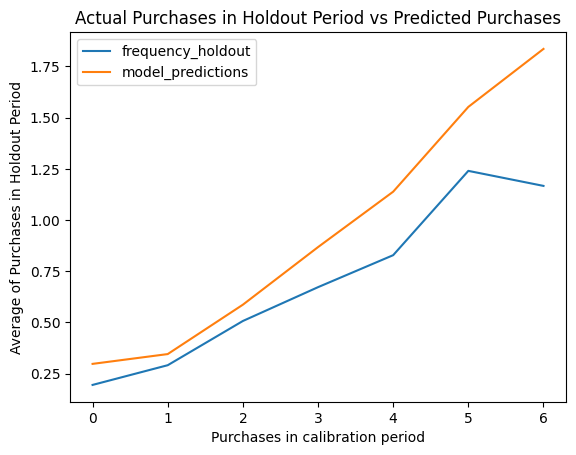

In [56]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# Biểu đồ so sánh số lần mua trung bình thực tế và dự đoán trong giai đoạn Holdout
plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)
plt.title("Actual Purchases in Holdout Period vs Predicted Purchases")
plt.show()

### Insight rõ ràng nhất từ biểu đồ này là gì?

*   **Xu hướng tỷ lệ thuận:** Khách hàng càng mua nhiều trong quá khứ (Calibration) thì càng có xu hướng mua nhiều hơn trong tương lai (Holdout). Cả thực tế và dự báo đều đi lên, cho thấy mô hình đã nắm bắt đúng quy luật hành vi.
*   **Mô hình đang dự báo hơi cao (Overestimation):** Đường màu cam (Dự báo) nằm hoàn toàn phía trên đường màu xanh (Thực tế). Điều này cho thấy mô hình đang hơi "lạc quan" và dự báo số lần mua hàng cao hơn so với những gì thực sự xảy ra. Bạn có thể cần điều chỉnh tham số `penalizer_coef` để làm mô hình khắt khe hơn.
*   **Sự lệch pha ở nhóm khách hàng trung thành nhất (X=6):** Tại điểm 6 đơn hàng, thực tế (đường xanh) bắt đầu đi xuống, nhưng mô hình (đường cam) vẫn dự báo tăng mạnh. 
    *   *Giải thích:* Nhóm khách hàng mua 6 lần có thể có số lượng quá ít, dẫn đến dữ liệu thực tế bị biến động (noise). Mô hình có xu hướng đi theo đường thẳng nên chưa bắt kịp sự sụt giảm này. Điều này nhắc nhở bạn nên cẩn trọng khi dự báo cho nhóm khách hàng cực kỳ năng nổ.

**Lời khuyên:** Dựa trên MAE và biểu đồ này, mô hình của bạn có độ chính xác tương đối về mặt xu hướng nhưng cần tinh chỉnh để giảm mức độ dự báo quá đà (đưa đường cam sát xuống đường xanh hơn).

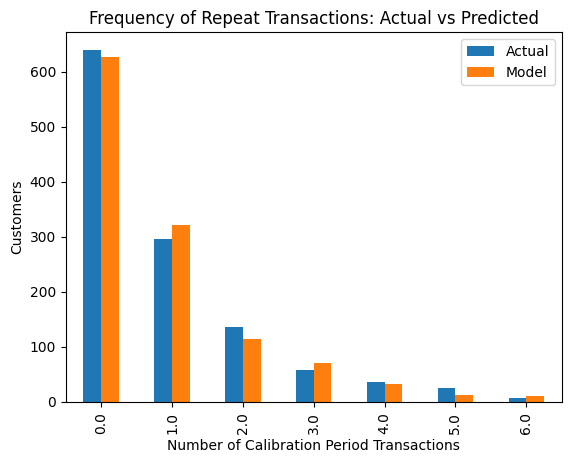

In [57]:
from lifetimes.plotting import plot_period_transactions

# So sánh tần suất giao dịch thực tế và dự đoán trên toàn bộ tập dữ liệu huấn luyện
plot_period_transactions(bgf)
plt.title("Frequency of Repeat Transactions: Actual vs Predicted")
plt.show()

## 3. Mô hình Gamma-Gamma

### Định nghĩa
Mô hình Gamma-Gamma được sử dụng để dự đoán **Giá trị giao dịch trung bình** (Monetary Value) của khách hàng trong tương lai.

### Tác dụng
*   Ước tính giá trị đơn hàng trung bình một cách khách quan, loại bỏ các nhiễu (outliers) trong ngắn hạn.
*   Kết hợp với BG/NBD để tính toán giá trị CLV cuối cùng.

### Cơ sở toán học
Mô hình này hoạt động dựa trên giả định quan trọng: **Không có mối tương quan** giữa giá trị giao dịch (Monetary Value) và tần suất giao dịch (Frequency).
1.  Giá trị giao dịch của mỗi khách hàng dao động quanh giá trị trung bình của chính họ theo **Phân phối Gamma**.
2.  Giá trị giao dịch trung bình giữa các khách hàng khác nhau cũng tuân theo **Phân phối Gamma**.

### Công thức
Kỳ vọng về giá trị giao dịch trung bình $E(M)$ của một khách hàng có giá trị trung bình lịch sử là $m_x$ và số lần mua hàng là $x$:
$$E(M | p, q, \gamma, m_x, x) = \frac{\frac{q-1}{px + \gamma - 1} \cdot \gamma \cdot m_{avg} + x \cdot m_x}{\frac{q-1}{px + \gamma - 1} + x}$$

**Trong đó:**
*   $p, q, \gamma$: Các tham số của phân phối Gamma.
*   $m_x$: Giá trị đơn hàng trung bình quan sát được của khách hàng đó.
*   $x$: Số lượng giao dịch đã thực hiện.

In [58]:
from lifetimes import GammaGammaFitter

# 1. Lọc dữ liệu: Mô hình Gamma-Gamma yêu cầu khách hàng phải có giao dịch lặp lại
# Chúng ta sử dụng bảng summary_cal_holdout đã tạo ở bước trước
returning_customers_summary = summary_cal_holdout[summary_cal_holdout['frequency_cal'] > 0]

# 2. Kiểm tra điều kiện tiên quyết: Tương quan giữa Frequency và Monetary Value
# Hệ số tương quan nên gần bằng 0 để mô hình đạt độ chính xác tốt nhất
correlation = returning_customers_summary[['frequency_cal', 'monetary_value_cal']].corr()
print(f"Correlation between Frequency and Monetary Value:\n{correlation}\n")

# 3. Khởi tạo và Huấn luyện mô hình Gamma-Gamma
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers_summary['frequency_cal'], 
        returning_customers_summary['monetary_value_cal'])

# 4. Dự đoán giá trị trung bình của các giao dịch trong tương lai (Expected Average Profit)
returning_customers_summary["expected_average_profit"] = ggf.conditional_expected_average_profit(
    returning_customers_summary['frequency_cal'],
    returning_customers_summary['monetary_value_cal']
)

# 5. Tính toán giá trị CLV cuối cùng cho mỗi khách hàng (trong 3 tháng tới)
# Kết hợp kết quả từ mô hình BG-NBD (bgf) và Gamma-Gamma (ggf)
returning_customers_summary['clv_3_months'] = ggf.customer_lifetime_value(
    bgf, # Mô hình BG-NBD đã fit ở bước trước
    returning_customers_summary['frequency_cal'],
    returning_customers_summary['recency_cal'],
    returning_customers_summary['T_cal'],
    returning_customers_summary['monetary_value_cal'],
    time=3, # Dự báo cho 3 tháng
    freq='D', # Đơn vị thời gian là ngày (D)
    discount_rate=0.01 # Tỷ lệ chiết khấu hàng tháng (tùy chọn)
)

print(returning_customers_summary[['expected_average_profit', 'clv_3_months']].sort_values(by='clv_3_months', ascending=False).head(10))

Correlation between Frequency and Monetary Value:
                    frequency_cal  monetary_value_cal
frequency_cal            1.000000            0.039188
monetary_value_cal       0.039188            1.000000

            expected_average_profit  clv_3_months
CustomerID                                       
12748                   2400.483205  19401.411873
15311                   4329.743015  16368.856375
14646                   2788.355925  12235.421826
17841                   2507.815462   9794.391807
14667                   4648.308803   8739.165057
14911                   1697.181451   8397.368167
14606                   1559.769424   7793.275093
13113                  10000.364364   6784.428682
15464                  15360.115679   6483.304178
15039                   4126.715090   6454.347272


In [59]:
# 1. Tính toán CLV dự kiến
# Lưu ý: Sử dụng dữ liệu từ tập returning_customers_summary (đã lọc frequency > 0)
# 'time' ở đây là số tháng bạn muốn dự báo (ví dụ: 12 tháng)
# 'freq' phải khớp với đơn vị của T_cal (thường là "D" - ngày)
clv_results = ggf.customer_lifetime_value(
    bgf,
    returning_customers_summary['frequency_cal'],
    returning_customers_summary['recency_cal'],
    returning_customers_summary['T_cal'],
    returning_customers_summary['monetary_value_cal'],
    time=12,           # Dự báo doanh thu trong 12 tháng tới
    freq="D",          # Đơn vị dữ liệu đầu vào là Ngày
    discount_rate=0.01 # Tỷ lệ chiết khấu (thường là 1% mỗi tháng)
)

# 2. Reset index để lấy lại cột CustomerID
clv_results = clv_results.reset_index()
clv_results.columns = ['CustomerID', 'CLV_Expected']

# 3. Gộp kết quả vào bảng summary ban đầu
# Dùng 'left join' để giữ lại thông tin RFM của khách hàng
final_report = returning_customers_summary.merge(clv_results, on="CustomerID", how="left")

# 4. Hiển thị Top 10 khách hàng giá trị nhất
print("--- Top 10 khách hàng có CLV dự kiến cao nhất ---")
print(final_report.sort_values(by="CLV_Expected", ascending=False).head(10))

--- Top 10 khách hàng có CLV dự kiến cao nhất ---
     CustomerID  frequency_cal  recency_cal  T_cal  monetary_value_cal  \
44        12748           33.0        250.0  267.0         2383.191774   
276       15311           15.0        263.0  273.0         4261.288500   
207       14646            8.0         89.0   89.0         2705.564029   
518       17841           15.0        258.0  264.0         2468.082299   
208       14667            6.0        183.0  203.0         4464.617625   
238       14911           19.0        260.0  264.0         1675.901888   
202       14606           19.0        252.0  259.0         1540.200019   
86        13113            2.0        141.0  181.0         8816.506600   
252       15039            5.0        200.0  211.0         3930.953304   
265       15194            5.0        155.0  200.0         3935.852056   

     frequency_holdout  monetary_value_holdout  duration_holdout  \
44                 0.0                0.000000              90.0   

Kết quả kiểm định mô hình Gamma-Gamma:
Mean Absolute Error (MAE): 1374.52
Root Mean Squared Error (RMSE): 2194.33


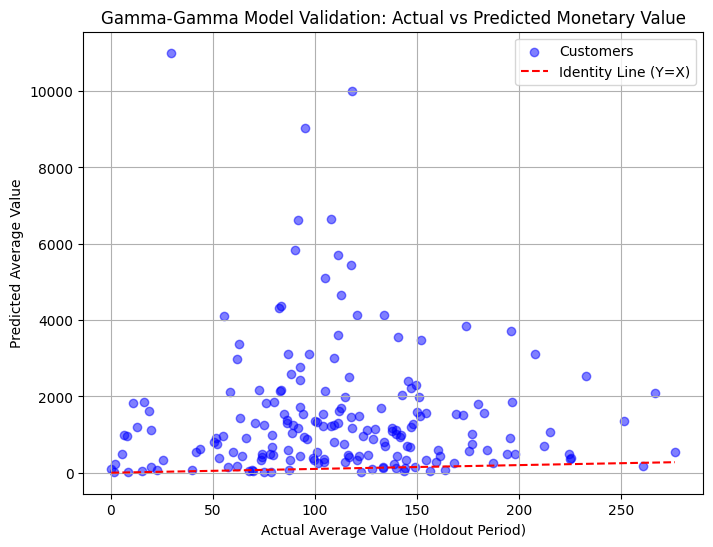

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Dự báo giá trị trung bình trên tập kiểm định (Holdout)
# Tính toán giá trị trung bình kỳ vọng dựa trên dữ liệu từ giai đoạn huấn luyện (Calibration)
expected_monetary = ggf.conditional_expected_average_profit(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['monetary_value_cal']
)

# 2. Lọc dữ liệu để kiểm định
# Chỉ giữ lại những khách hàng có giao dịch ở cả hai giai đoạn Calibration và Holdout
# Điều này đảm bảo chúng ta có giá trị thực tế (Actual) để so sánh với dự báo (Predicted)
mask = (summary_cal_holdout['frequency_holdout'] > 0) & (summary_cal_holdout['frequency_cal'] > 0)
actual_monetary = summary_cal_holdout.loc[mask, 'monetary_value_holdout']
predicted_monetary = expected_monetary[mask]

# 3. Tính toán các chỉ số sai số (MAE và RMSE)
mae_gg = mean_absolute_error(actual_monetary, predicted_monetary)
rmse_gg = np.sqrt(mean_squared_error(actual_monetary, predicted_monetary))

print(f"Kết quả kiểm định mô hình Gamma-Gamma:")
print(f"Mean Absolute Error (MAE): {mae_gg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gg:.2f}")

# 4. Trực quan hóa kết quả kiểm định
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ phân tán (Scatter plot) thể hiện từng khách hàng
plt.scatter(actual_monetary, predicted_monetary, color='blue', alpha=0.5, label='Customers')

# Vẽ đường lý tưởng Y = X (nơi dự báo bằng chính xác thực tế)
plt.plot([actual_monetary.min(), actual_monetary.max()], 
         [actual_monetary.min(), actual_monetary.max()], 
         color='red', linestyle='--', label='Identity Line (Y=X)')

plt.xlabel('Actual Average Value (Holdout Period)')
plt.ylabel('Predicted Average Value')
plt.title('Gamma-Gamma Model Validation: Actual vs Predicted Monetary Value')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
print(summary_cal_holdout.columns)


Index(['frequency_cal', 'recency_cal', 'T_cal', 'monetary_value_cal',
       'frequency_holdout', 'monetary_value_holdout', 'duration_holdout',
       'expected_purc_1_month', 'expected_purc_3_month'],
      dtype='str')


In [62]:
# 1. Tính toán giá trị CLV thực tế (Actual Monetary) trong giai đoạn Holdout
# Dựa trên nguyên lý kiểm định Gamma-Gamma trong file, ta lấy giá trị tiền tệ thực tế trong thời gian Holdout
actual_monetary_holdout = summary_cal_holdout.reset_index()[['CustomerID', 'monetary_value_holdout']]
actual_monetary_holdout.columns = ['CustomerID', 'Actual_CLV_Holdout']

# 2. Gộp CLV thực tế vào bảng final_report hiện có
final_report = final_report.merge(actual_monetary_holdout, on='CustomerID', how='left')

# Hiển thị Top 10 khách hàng để quan sát sự chênh lệch
print("--- So sánh CLV Dự báo (3 tháng) và Thực tế (Holdout) ---")
print(final_report[['CustomerID', 'clv_3_months', 'Actual_CLV_Holdout']].sort_values(by='clv_3_months', ascending=False).head(10))

--- So sánh CLV Dự báo (3 tháng) và Thực tế (Holdout) ---
     CustomerID  clv_3_months  Actual_CLV_Holdout
44        12748  19401.411873            0.000000
276       15311  16368.856375           82.602359
207       14646  12235.421826            0.000000
518       17841   9794.391807          116.837964
208       14667   8739.165057            0.000000
238       14911   8397.368167          112.614051
202       14606   7793.275093          154.542628
86        13113   6784.428682          118.169561
289       15464   6483.304178            0.000000
252       15039   6454.347272          120.876498


Việc có sự khác biệt giữa hai cách tính này là do mục đích sử dụng khác nhau trong quy trình phân tích dữ liệu. Dưới đây là lý do tại sao chúng khác biệt và tại sao  không nên sửa lại công thức tính thực tế theo công thức định nghĩa ban đầu.  

1. Tại sao hai công thức lại khác nhau?

Sự khác biệt nằm ở chỗ một bên là mô hình lý thuyết và một bên là giá trị quan sát thực tế:

Công thức ban đầu ($CLV = AOV \times Frequency \times 1/Churn$): Đây là công thức mang tính định nghĩa/dự báo. Nó dùng để ước tính giá trị mà một khách hàng có thể mang lại trong suốt cuộc đời của họ dựa trên các giả định trung bình về chi tiêu và lòng trung thành.  

Công thức thực tế trong Holdout ($\sum total\_revenue$): Đây là giá trị thực tế (Ground Truth). Trong giai đoạn kiểm định (Holdout), chúng ta không cần dự báo nữa mà cần biết chính xác khách hàng đã trả bao nhiêu tiền. Doanh thu thực tế phát sinh là thước đo chuẩn xác nhất để đánh giá xem mô hình dự báo bên trên có chạy đúng hay không.  

2. Tại sao không thể sửa lại thành công thức ban đầu?

Không nên sửa công thức tính thực tế trong giai đoạn Holdout vì những lý do sau:

Mất đi tính kiểm định: Mục đích của việc tính Actual CLV Holdout là để làm "đáp án". Nếu  dùng công thức dự báo (với các biến $AOV, Frequency$) để tính cho giai đoạn Holdout,  chỉ đang so sánh hai con số dự báo với nhau chứ không phải so sánh dự báo với thực tế.  

Sai lệch về thời gian: Công thức $1/Churn$ thường tính cho toàn bộ vòng đời tương lai của khách hàng (có thể kéo dài nhiều năm). Trong khi đó, giai đoạn Holdout trong file chỉ giới hạn trong 90 ngày. Việc áp dụng công thức "vòng đời" vào một khoảng thời gian ngắn 90 ngày sẽ khiến con số bị phóng đại và không chính xác.  

Sự kết hợp trong mô hình: Thực tế, mô hình Gamma-Gamma kết hợp với BG/NBD trong code chính là phiên bản nâng cao của công thức ban đầu:  

BG/NBD dự báo $Frequency$ và khả năng sống sót ($1/Churn$).  

Gamma-Gamma dự báo $AOV$.  

3. Kết luận

  

Dự báo (Predicted CLV): Sử dụng các mô hình xác suất phức tạp để ước tính giá trị tương lai.  

Thực tế (Actual CLV): Luôn phải là tổng số tiền thực sự thu được trong một khoảng thời gian để làm thước đo độ chính xác.  
 

# CÁCH 2: SỬ DỤNG MÔ HÌNH HỌC MÁY


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             52924 non-null  int64         
 1   Transaction_ID         52924 non-null  int64         
 2   Transaction_Date       52924 non-null  datetime64[us]
 3   Month                  52924 non-null  str           
 4   Date                   52924 non-null  str           
 5   Week                   52924 non-null  str           
 6   Product_SKU            52924 non-null  str           
 7   Product_Description    52924 non-null  str           
 8   Product_Category       52924 non-null  str           
 9   ABC                    52924 non-null  str           
 10  Quantity               52924 non-null  int64         
 11  Avg_Price              52924 non-null  float64       
 12  Delivery_Charges       52924 non-null  float64       
 13  Revenue     

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# XỬ LÝ THỜI GIAN VÀ CHIA TÁCH DỮ LIỆU
# ---------------------------------------------------------
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

end_date = df['Transaction_Date'].max()
cutoff_date = end_date - pd.Timedelta(days=90)

cal_df = df[df['Transaction_Date'] <= cutoff_date]
holdout_df = df[df['Transaction_Date'] > cutoff_date]

# ---------------------------------------------------------
# FEATURE ENGINEERING 
# ---------------------------------------------------------
features = cal_df.groupby('CustomerID').agg(
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),
    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),
    
    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),
    
    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),
    total_delivery_fee=('Delivery_Charges', 'sum'),
    
    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),
    
    Tenure_Months=('Tenure_Months', 'first'),
    Gender=('Gender', 'first'),
    Location=('Location', 'first')
).reset_index()

features['recency_cal'] = (features['last_purchase'] - features['first_purchase']).dt.days
features['T_cal'] = (cutoff_date - features['first_purchase']).dt.days
features['monetary_avg'] = features['monetary_sum'] / features['frequency_cal']

features = features.drop(columns=['first_purchase', 'last_purchase'])
features = pd.get_dummies(features, columns=['Gender', 'Location'], drop_first=True)

# ---------------------------------------------------------
# TẠO NHÃN MỤC TIÊU (TARGET - Y)
# ---------------------------------------------------------
target = holdout_df.groupby('CustomerID').agg(
    actual_clv_90d=('total_revenue', 'sum')
).reset_index()

ml_df = pd.merge(features, target, on='CustomerID', how='left')
ml_df['actual_clv_90d'] = ml_df['actual_clv_90d'].fillna(0)

# ---------------------------------------------------------
# CHIA TẬP TRAIN / TEST
# ---------------------------------------------------------
X = ml_df.drop(columns=['CustomerID', 'actual_clv_90d'])
y = ml_df['actual_clv_90d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# FEATURE SELECTION BẰNG RANDOM FOREST
# ---------------------------------------------------------
print("--- TIẾN HÀNH LỰA CHỌN ĐẶC TRƯNG ---")
selector_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
selector_rf.fit(X_train, y_train)

selector = SelectFromModel(selector_rf, prefit=True, threshold='mean')

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_cols = X_train.columns[selector.get_support()]
print(f"Số lượng features ban đầu: {X_train.shape[1]}")
print(f"Số lượng features được chọn: {len(selected_cols)}")
print(f"Các features được chọn: {list(selected_cols)}\n")

# ---------------------------------------------------------
# PARAMETER TUNING VÀ SO SÁNH CÁC MÔ HÌNH
# ---------------------------------------------------------
# Định nghĩa các mô hình và không gian siêu tham số (Parameter Grids)
models_and_params = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [4, 6, 8, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
        }
    }
}

results = []
best_models = {}

print("--- BẮT ĐẦU PARAMETER TUNING VÀ SO SÁNH MÔ HÌNH ---")
for name, mp in models_and_params.items():
    print(f"\nĐang Tuning mô hình: [{name}]...")
    
    # Sử dụng RandomizedSearchCV để tìm tham số tối ưu (chọn ngẫu nhiên 15 tổ hợp để tiết kiệm thời gian)
    random_search = RandomizedSearchCV(
        estimator=mp["model"],
        param_distributions=mp["params"],
        n_iter=15,                           # Số lần thử nghiệm ngẫu nhiên
        scoring='neg_mean_absolute_error',   # Tối ưu hóa trên thước đo MAE
        cv=3,                                # K-fold cross-validation = 3
        verbose=1,                           # In tiến trình
        random_state=42,
        n_jobs=-1                            # Tận dụng toàn bộ CPU
    )
    
    # Huấn luyện tuning trên dữ liệu đã Feature Selection
    random_search.fit(X_train_sel, y_train)
    
    # Lấy mô hình có bộ tham số tốt nhất
    best_model = random_search.best_estimator_
    best_models[name] = best_model
    
    print(f"Tham số tốt nhất cho {name}: {random_search.best_params_}")
    
    # Dự báo với mô hình tốt nhất
    y_pred = best_model.predict(X_test_sel)
    y_pred = np.maximum(y_pred, 0) # Không cho phép CLV âm
    
    # Đánh giá Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    print(f"-> Kết quả Test: MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

# ---------------------------------------------------------
# BẢNG TỔNG KẾT KẾT QUẢ SO SÁNH CÁC MÔ HÌNH
# ---------------------------------------------------------
print("\n--- BẢNG TỔNG KẾT SO SÁNH CÁC MÔ HÌNH ĐÃ TUNING ---")
results_df = pd.DataFrame(results).sort_values(by='MAE') # Sắp xếp từ tốt nhất đến kém nhất theo MAE
print(results_df.to_string(index=False))

--- TIẾN HÀNH LỰA CHỌN ĐẶC TRƯNG ---
Số lượng features ban đầu: 19
Số lượng features được chọn: 10
Các features được chọn: ['frequency_cal', 'monetary_sum', 'total_quantity', 'avg_discount', 'total_delivery_fee', 'total_offline', 'total_online', 'total_marketing', 'recency_cal', 'monetary_avg']

--- BẮT ĐẦU PARAMETER TUNING VÀ SO SÁNH MÔ HÌNH ---

Đang Tuning mô hình: [Random Forest]...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tham số tốt nhất cho Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 4}
-> Kết quả Test: MAE: 946.83 | RMSE: 1770.02 | R2: 0.1880

Đang Tuning mô hình: [Gradient Boosting]...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tham số tốt nhất cho Gradient Boosting: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01}
-> Kết quả Test: MAE: 983.76 | RMSE: 1798.22 | R2: 0.1619

Đang Tuning mô hình: [XGBoost]...
Fitting 3 folds for each of 15 candidates, totalling

Mo thử chạy model ở đây nè

# Tổng hợp các thay đổi khi tối ưu mô hình CLV

So với phiên bản CLV ban đầu, mô hình cuối cùng đã được cải thiện thông qua các thay đổi chính sau:

---

## 1. Sửa lại cách tính Recency

### Vấn đề ở code ban đầu
Ban đầu biến `recency_cal` được tính gần giống:

last_purchase - first_purchase

Cách này thực chất đo **thời gian tồn tại của khách hàng (customer lifespan)**, không phải recency.

### Cải tiến
Đã sửa lại thành:

Recency = cutoff_date - last_purchase

### Ý nghĩa
Biến này giờ đo đúng:

> Khách hàng đã bao lâu chưa quay lại mua hàng.

### Tác động
- Phản ánh đúng mức độ active/inactive của khách hàng
- Tăng chất lượng tín hiệu cho mô hình

---

## 2. Loại bỏ Feature Selection

### Cách làm ban đầu
Sử dụng Random Forest + SelectFromModel để chỉ giữ lại một số features quan trọng.

### Cải tiến
Bỏ hoàn toàn bước feature selection, sử dụng toàn bộ feature đã tạo.

### Lý do
Các mô hình tree-based như:
- Random Forest
- XGBoost

có khả năng tự học feature importance và interaction khá tốt.

### Tác động
Giữ lại được nhiều tín hiệu hữu ích như:
- Hành vi mua hàng
- Khu vực khách hàng
- Customer segment
- Xu hướng mua gần đây

---

## 3. Thêm biến phân khúc khách hàng (KMeans_Label)

### Cải tiến
Thêm biến `KMeans_Label` vào mô hình.

Biến này được tạo bằng KMeans clustering dựa trên 3 chỉ số RFM:
- Recency
- Frequency
- Monetary

### Ý nghĩa
Mô hình giờ không chỉ nhìn từng hành vi riêng lẻ, mà còn biết:

> Khách hàng thuộc nhóm nào.

Ví dụ:
- Loyal customers
- High-value customers
- At-risk customers

### Tác động
Đây là một trong những feature quan trọng nhất trong mô hình.

---

## 4. Thêm các biến hành vi gần đây (30 ngày gần nhất)

### Cải tiến
Tạo thêm các biến:

- `freq_last30`: số lần mua trong 30 ngày gần nhất
- `spend_last30`: tổng chi tiêu 30 ngày gần nhất
- `qty_last30`: tổng số lượng sản phẩm mua gần đây

### Ý nghĩa
Giúp mô hình biết:

> Gần đây khách còn active hay không.

### Tác động
Giúp dự đoán CLV tốt hơn so với chỉ dùng dữ liệu lịch sử tổng quát.

---

## 5. Thêm Momentum Features (Xu hướng mua hàng)

### Cải tiến
Tạo thêm:

### Purchase Momentum

purchase_momentum = freq_last30 / frequency_cal

### Spend Momentum

spend_momentum = spend_last30 / monetary_sum

### Ý nghĩa
Đo xem khách hàng hiện tại đang:

- Mua nhiều hơn trước
- Mua ổn định
- Mua ít dần

Ví dụ:
Một khách từng mua nhiều nhưng gần đây không mua nữa → momentum thấp.

### Tác động
Giúp mô hình hiểu được:

> Xu hướng hành vi của khách hàng, không chỉ lịch sử.

---

## 6. Thêm biến nhịp độ mua hàng

### Cải tiến
Tạo biến:

avg_order_interval = T_cal / frequency_cal

### Ý nghĩa
Đo khoảng cách trung bình giữa các lần mua.

Phân biệt được:
- Khách mua đều đặn
- Khách mua theo đợt

### Tác động
Giúp mô hình hiểu rõ hơn về thói quen mua hàng.

---

## 7. Xử lý outlier của target CLV

### Cải tiến
Giới hạn các giá trị CLV quá lớn bằng percentile 98:

y = clip(y, 0, P98)

### Ý nghĩa
Giảm ảnh hưởng của một số khách hàng chi tiêu cực lớn.

### Tác động
Cải thiện rõ:
- MAE
- RMSE
- R²

---

## 8. Thêm khả năng giải thích mô hình

### Cải tiến
Phân tích feature importance của XGBoost.

### Mục tiêu
Xác định yếu tố nào ảnh hưởng mạnh nhất đến CLV.

### Top features quan trọng
- KMeans_Label
- Frequency
- Recent Quantity
- Offline Spending
- Marketing Spend

---

# Kết quả cuối cùng

## Phiên bản ban đầu

R² ≈ 0.18

## Phiên bản sau tối ưu

R² ≈ 0.63

## Mức cải thiện

Tăng hơn 3 lần khả năng dự đoán của mô hình.

---

# Kết luận

Sau khi cải thiện feature engineering, bổ sung customer segmentation, hành vi gần đây, xu hướng mua hàng, nhịp độ mua và xử lý outlier, mô hình CLV đã cải thiện đáng kể cả về độ chính xác lẫn khả năng giải thích business.

In [65]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. TIME SPLIT
# =========================================================
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

end_date = df['Transaction_Date'].max()
cutoff_date = end_date - pd.Timedelta(days=90)

cal_df = df[df['Transaction_Date'] <= cutoff_date].copy()
holdout_df = df[df['Transaction_Date'] > cutoff_date].copy()

# Recent window (30 days before cutoff)
recent_cutoff = cutoff_date - pd.Timedelta(days=30)

recent_df = cal_df[
    cal_df['Transaction_Date'] >= recent_cutoff
].copy()


# =========================================================
# 2. BASE FEATURES
# =========================================================
features = cal_df.groupby('CustomerID').agg(
    
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),

    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),

    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),

    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),

    total_delivery_fee=('Delivery_Charges', 'sum'),

    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),

    Tenure_Months=('Tenure_Months', 'first'),

    Gender=('Gender', 'first'),
    Location=('Location', 'first'),

    KMeans_Label=('KMeans_Label', 'first')

).reset_index()


# =========================================================
# 3. RFM + CUSTOMER AGE FEATURES
# =========================================================
features['recency_cal'] = (
    cutoff_date - features['last_purchase']
).dt.days

features['T_cal'] = (
    cutoff_date - features['first_purchase']
).dt.days

features['monetary_avg'] = (
    features['monetary_sum'] /
    (features['frequency_cal'] + 1)
)

features['avg_order_interval'] = (
    features['T_cal'] /
    (features['frequency_cal'] + 1)
)

# =========================================================
# 4. RECENT TREND FEATURES (LAST 30 DAYS)
# =========================================================
recent_features = recent_df.groupby('CustomerID').agg(
    
    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')

).reset_index()


features = pd.merge(
    features,
    recent_features,
    on='CustomerID',
    how='left'
)


# fill missing customers
recent_cols = [
    'freq_last30',
    'spend_last30',
    'qty_last30'
]

features[recent_cols] = (
    features[recent_cols]
    .fillna(0)
)


# =========================================================
# 5. MOMENTUM FEATURES
# =========================================================
features['purchase_momentum'] = (
    features['freq_last30'] /
    (features['frequency_cal'] + 1)
)

features['spend_momentum'] = (
    features['spend_last30'] /
    (features['monetary_sum'] + 1)
)


# =========================================================
# 6. DROP DATE COLUMNS
# =========================================================
features = features.drop(
    columns=[
        'first_purchase',
        'last_purchase'
    ]
)


# =========================================================
# 7. ENCODE CATEGORICAL
# =========================================================
features = pd.get_dummies(
    features,
    columns=[
        'Gender',
        'Location',
        'KMeans_Label'
    ],
    drop_first=True
)


# =========================================================
# 8. TARGET (NEXT 90 DAYS CLV)
# =========================================================
target = holdout_df.groupby('CustomerID').agg(
    actual_clv_90d=('total_revenue', 'sum')
).reset_index()


ml_df = pd.merge(
    features,
    target,
    on='CustomerID',
    how='left'
)

ml_df['actual_clv_90d'] = (
    ml_df['actual_clv_90d']
    .fillna(0)
)


# =========================================================
# 9. TRAIN / TEST SPLIT
# =========================================================
X = ml_df.drop(
    columns=[
        'CustomerID',
        'actual_clv_90d'
    ]
)

# giữ scale gốc trước, dễ interpret
y = ml_df['actual_clv_90d'].copy()

# Cap outliers (99th percentile)
upper = y.quantile(0.98)

y = np.clip(
    y,
    0,
    upper
)

print(f"Target capped at: {upper:.2f}")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================================================
# 10. MODELS + PARAMETER SEARCH
# =========================================================
models_and_params = {

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [4, 6, 8, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            random_state=42
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
        }
    }
}


# =========================================================
# 11. TRAIN + EVALUATE
# =========================================================
results = []

print("\n--- START TRAINING ---")

for name, mp in models_and_params.items():

    print(f"\nTuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=mp["model"],
        param_distributions=mp["params"],
        n_iter=15,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    best_model = random_search.best_estimator_
    # Feature importance (chỉ in cho XGBoost)
        
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values(
        by='importance',
        ascending=False
    )

    print("\nTop 15 Important Features:")
    print(importance.head(15))

    print(
        "Best Params:",
        random_search.best_params_
    )

    # Predict
    y_pred = best_model.predict(X_test)

    # no negative CLV
    y_pred = np.maximum(
        y_pred,
        0
    )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(
        f"MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f} | "
        f"R2: {r2:.4f}"
    )


# =========================================================
# 12. FINAL RESULTS
# =========================================================
results_df = pd.DataFrame(
    results
).sort_values(
    by='R2 Score',
    ascending=False
)

print("\n--- FINAL RESULTS ---")
print(
    results_df.to_string(
        index=False
    )
)

Target capped at: 6642.72

--- START TRAINING ---

Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               feature  importance
26      KMeans_Label_2    0.229101
25      KMeans_Label_1    0.156868
11         recency_cal    0.108406
1         monetary_sum    0.100956
6   total_delivery_fee    0.088310
9      total_marketing    0.044221
2       total_quantity    0.036824
7        total_offline    0.032699
13        monetary_avg    0.027066
8         total_online    0.024822
10       Tenure_Months    0.021925
5    coupon_usage_rate    0.020424
3    unique_categories    0.019389
12               T_cal    0.018825
14  avg_order_interval    0.018655
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 6}
MAE: 502.36 | RMSE: 987.61 | R2: 0.6259

Tuning Gradient Boosting...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               featu